# 轻松上手心理学数据分析：第二关

> 🔈 经过上一关，我们已经对 pandas 的使用有了基础的了解，包括常用的数据清洗和可视化，
> 
> 接下来我们将继续学习 pandas 的一些高级功能，并结合 numpy 进行数据生成和处理。以及使用 matplotlib 和 seaborn 进行数据可视化。


## 🌟 目标解锁 🚀📊 
1. 数据生成和处理
2. 重编码和反向计分
3. 数据可视化 

### 🌐背景介绍  
闯关题所涉及的数据集来源于2019年发表在nature communication上的一篇文章：  

Eisenberg, I. W., Bissett, P. G., Zeynep Enkavi, A., Li, J., MacKinnon, D. P., Marsch, L. A., & Poldrack, R. A. (2019). Uncovering the structure of self-regulation through data-driven ontology discovery. Nature Communications, 10(1), Article 1. https://doi.org/10.1038/s41467-019-10301-1  

在这篇文章中，研究者对自我控制相关的范式和问卷进行了系统的总结，同时公开了收集到的数据集。  

数据集挂载路径为 '/home/mw/input/84988498/demographic_health.csv'  

In [1]:
# 导入必要的工具包
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置随机种子，以确保每次运行时生成的随机数相同，从而保证实验结果可重复
np.random.seed(123)

In [2]:
df = pd.read_csv("/Users/ss/Documents/PyBayesian/Archive/2023/data/demographic_health.csv")

In [8]:
# 尝试读取指定路径下的CSV文件
try:
    # 尝试从第一个路径读取文件
    df = pd.read_csv("/home/mw/input/bayes3797/demographic_health.csv")
except:
    # 如果第一个路径失败，则从备用路径读取文件
    df = pd.read_csv("../data/demographic_health.csv")

## STEP1：数据编码 

1. 问题q1：将数据中`Sex`列的值进行转换，其中0表示`female`，1表示`male`。
      - 提示：可以使用 `df.map()`、`df.replace()` 等方法，尽量不要使用 `if else` 等方法。
2. 问题q2：对于数据中的 `EverythingIsEffort` 列进行方向计分编码。
      - 要求，将其中的值 4重新编码为0，将3重新编码为1，将2重新编码为2，将1重新编码为3，将0重新编码为4） 并生成新的一列 `EverythingIsEffort_recode`。

In [3]:
# 问题q1：将数据中`Sex`列的值进行转换，其中0表示`female`，1表示`male`
# 提示：df.map() 是对 Series（单列）进行元素级映射的非常简单的函数。我们可以传入一个字典，将数值映射到对应的字符串。
# 提示：df.replace() 则可以用于替换 DataFrame 中的值，既可以替换列中的值，也可以进行多列的替换。
df["Sex"] = df['Sex'].map({0:'female',1:'male'})

# 问题q2：对于数据中的 `EverythingIsEffort` 列进行方向计分编码(值 4重新编码为0，将3重新编码为1，将2重新编码为2，将1重新编码为3，将0重新编码为4)。
df["EverythingIsEffort_recode"] = df['EverythingIsEffort'].map({})

## STEP2：数据生成和处理

1. 问题q1：使用 `df.query()` 方法筛选出，种族(Race)为 "White" 年龄(Age)小于60的被试。新数据框命名为 `df2`。
2. 问题q2: 进行多列选择和求和。选择 df2 中的列 "Nervous","Hopeless","RestlessFidgety","Depressed","EverythingIsEffort_recode","Worthless"，并进行求和。求和得到的新列为 `sum`。
3. 问题q3: 假设总分(sum)和被试的年龄相关，并且受到性别的影响，进而假设为不同性别的被试生成预测数据。
      - 男性的预测数据计算方法为：2*Age + 5
      - 女性的预测数据计算方法为：3*Age + 2
      - 新列命名为 `predict`。
      - 提示：可通过 `df2.loc` 索引出性别列，并使用 `apply()` 方法进行计算。

In [5]:
# 问题q1：使用`df.query()`方法筛选出，种族(Race)为 "White" 年龄(Age)小于60的被试。新数据框命名为 `df2`
# 提示：`df.query()`方法可以允许通过字符串形式对DataFrame进行查询。例如，df.query（'A>B'）将返回列A中大于列B的所有行。
df2 = df.query('Race == "White" & Age < 60')

# 问题q2: 进行多列选择和求和, 得到的新列为 `sum`。
# 提示：选择 df2 中的指定列，再通过 sum(axis=1) 来进行按行求和，生成一个新的列 sum。
df2['sum'] = df2[['Nervous', 'Hopeless', 'RestlessFidgety', 'Depressed', 'EverythingIsEffort_recode', 'Worthless']].sum(axis=1)

/var/folders/yk/78rqxlxn4pz_rsb5_31xvh340000gn/T/ipykernel_54330/3805827509.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['sum'] = df2[['Nervous', 'Hopeless', 'RestlessFidgety', 'Depressed', 'EverythingIsEffort_recode', 'Worthless']].sum(axis=1)


In [22]:
# 问题q3: 为不同性别的被试生成预测数据。
# 提示：可通过 `df2.loc` 索引出性别列，并使用 `apply()` 方法进行计算。
df2.loc[df2['Sex'] == 'male', 'predict'] = 2 * df2['Age'] + 5
df2.loc[df2['Sex'] == 'female', 'predict'] = 3 * df2['Age'] + 2
# df2["predict"] = ...

## STEP3: 可视化

1. 问题q1：基于 `df2`，使用 `matplotlib` 中的 `scatter` 函数，绘制 `predict`(即x轴)对`sum`(即y轴)的预测图。
2. 问题q2：使用 `sns.regplot` 绘制`predict`(即x)对`sum`(即y)的回归图。
      - 要求：需要带有散点图、线性拟合线和误差范围。
3. 问题q3：使用 seaborn 的 `FacetGrid` 方法，绘制不同性别(Sex)下，`predict`(即x)对`sum`(即y)的回归图。

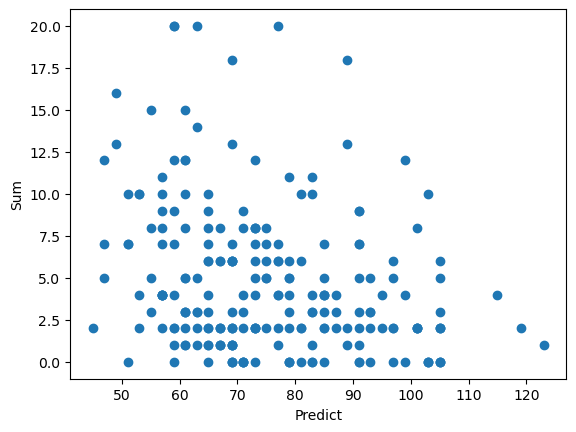

In [8]:
# 问题q1：基于 `df2`，使用 `matplotlib` 中的 `scatter` 函数，绘制 `predict`(即x轴)对`sum`(即y轴)的预测图。
# 提示：使用 scatter 函数：调用 plt.scatter() 函数，将 predict 作为 x 轴数据，sum 作为 y 轴数据。
# plt.scatter(...)
# plt.show()

plt.scatter(df2['predict'], df2['sum'])
plt.xlabel('Predict')
plt.ylabel('Sum')
plt.show()


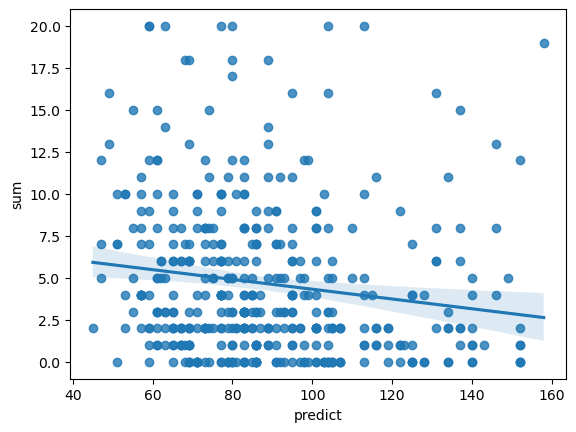

In [24]:
# 问题q2：使用 `sns.regplot` 绘制`predict`(即x)对`sum`(即y)的回归图。
sns.regplot(x='predict', y='sum', data=df2)
plt.show()


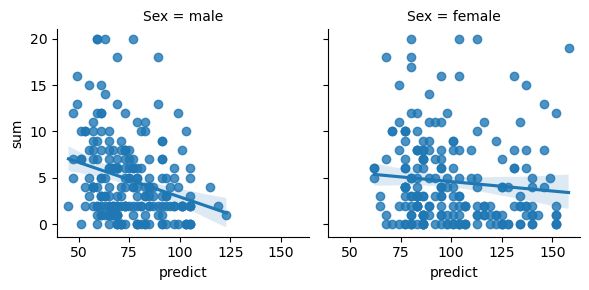

In [23]:
# 问题q3：使用 seaborn 的 `FacetGrid` 方法，绘制不同性别下，`predict`(即x)对`sum`(即y)的回归图。
grid = sns.FacetGrid(df2, col='Sex', aspect=1)
grid.map(sns.regplot, 'predict', 'sum')
plt.show()


## STEP4：将结果保存为 csv 文件  
💡 这一步的代码你无需修改，直接运行即可。

In [25]:
# 运行这两个cell,生成答案文件；
# 该文件在左侧文件树project工作区下，你可以自行右击下载或者读取查看

df.to_csv("result21.csv", index=None)
df2.to_csv("result22.csv", index=None)

## STEP5: 提交 csv 文件，获取分数结果  
经过上述几个步骤，你的 csv 答案文件已经准备完毕了，最后让我们提交答案文件，看看是否正确。  

**提交方法：**  

1、拷贝提交 token  

去对应关卡的 [提交页面](https://www.heywhale.com/home/competition/652df88ecf318d693e2b20de/submit)，找到闯关题 2 任务，看到了你的 token 嘛？  
拷贝它。  

> 记得：每个任务的 token 不一样。  

2、粘贴到下方 cell 里，替换 XXXXXXX， Shift+Enter，运行 。

In [26]:
# 运行这个Cell 下载提交工具

!wget -nv -O heywhale_submit https://cdn.kesci.com/submit_tool/v4/heywhale_submit&&chmod +x heywhale_submit

# 运行提交工具
# 把下方XXXXXXX替换为你的 Token
# 改完看起来像是：!./heywhale_submit -token 586eeef71cb92941 -file answer_psy_1_2.csv

!./heywhale_submit -token XXXXXXX -file answer_psy_1_2.csv  # 替换XXXXXXX；注意不可增减任何空格或其他字符

zsh:1: command not found: wget
zsh:1: no such file or directory: ./heywhale_submit


运行成功、显示提交完成后，即可去 [提交页面](https://www.heywhale.com/home/competition/652df88ecf318d693e2b20de/submit) 看成绩。满分即可继续完成下个闯关题。  

没有成功也不怕，看下报错信息，对照教案与[小黄鸭 debug 法](https://baike.baidu.com/item/%E5%B0%8F%E9%BB%84%E9%B8%AD%E8%B0%83%E8%AF%95%E6%B3%95/16569594)排查下，改完重新走 STEP 5、6 提交咯。